In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
EKSTRAKSI WAVEFORM KE JSON (1C dan 3C)
- 1C: hanya komponen Z (semua event yang memiliki Z)
- 3C: hanya event dengan Z, N, E lengkap
- Preprocessing: detrend, resample 100 Hz, normalisasi max 9 detik setelah P
- STA/LTA untuk P-wave picking (FALLBACK TELAH DIPERBAIKI)
- Parallel processing dengan resume
"""

import os
import sys
import json
import numpy as np
from pathlib import Path
from obspy import read, UTCDateTime, Stream
from obspy.signal.trigger import recursive_sta_lta
from tqdm import tqdm
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import pandas as pd

# =============================================
# 1. KONFIGURASI
# =============================================

WAVEFORM_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon_juli'
OUTPUT_JSON_1C = '/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c.json'
OUTPUT_JSON_3C = "/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_3c.json"
LOG_FILE = "extract_waveforms_both.log"

# Parameter MCU-Quake
SAMPLE_RATE = 100.0
SIG_DURATION = 7.0
NOISE_DURATION = 7.0
NORM_WINDOW = 9.0

# Parameter STA/LTA
STA_WIN = 0.5
LTA_WIN = 15.0
TRIGGER_THRESHOLD = 2.5

# Parallel
MAX_WORKERS = 8

# Ukuran file minimum (skip file corrupt/kecil)
MIN_FILE_SIZE_BYTES = 1024  # 1 KB

# =============================================
# 2. SETUP LOGGING
# =============================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

# =============================================
# 3. FUNGSI PREPROCESSING (DIPERBAIKI)
# =============================================

def pick_p_arrival(trace):
    """
    Deteksi P-wave arrival menggunakan STA/LTA.
    Fallback: cari puncak maksimum dalam jendela 0-15 detik SETELAH origin.
    """
    try:
        sr = trace.stats.sampling_rate
        sta_n = int(STA_WIN * sr)
        lta_n = int(LTA_WIN * sr)
        
        if len(trace.data) < lta_n + sta_n:
            return trace.stats.starttime + 5.0
        
        cft = recursive_sta_lta(trace.data, sta_n, lta_n)
        trigger_indices = np.where(cft > TRIGGER_THRESHOLD)[0]
        
        if len(trigger_indices) > 0:
            pick_idx = trigger_indices[0]
            if 0 < pick_idx < len(trace.data):
                return trace.stats.starttime + pick_idx / sr
        
        # ===== FALLBACK YANG DIPERBAIKI =====
        # Cari puncak maksimum dalam 15 detik SETELAH origin (bukan dari awal trace)
        # Asumsikan origin berada di sekitar sampel ke-30*sr (karena TIME_BEFORE=30)
        origin_sample = int(30 * sr)  # 30 detik setelah awal trace
        
        # Cari dalam rentang origin_sample hingga origin_sample + 15*sr
        start_idx = max(0, origin_sample)
        end_idx = min(len(trace.data), origin_sample + int(15 * sr))
        
        if end_idx > start_idx:
            max_idx = np.argmax(np.abs(trace.data[start_idx:end_idx])) + start_idx
            if max_idx > 0:
                return trace.stats.starttime + max_idx / sr
        
    except Exception as e:
        logger.debug(f"Error in pick_p_arrival: {e}")
    
    # Fallback terakhir: ambil 5 detik setelah origin
    return trace.stats.starttime + 35.0  # origin + 5 detik (karena origin di 30 detik)

def extract_component_windows(trace, p_time):
    """Ekstraksi sinyal dan noise untuk satu trace komponen."""
    try:
        # Sinyal 7 detik setelah P
        tr_signal = trace.copy().trim(p_time, p_time + SIG_DURATION)
        # Noise 7 detik sebelum P
        tr_noise = trace.copy().trim(p_time - NOISE_DURATION, p_time)
        
        # Detrend
        tr_signal.detrend('simple')
        tr_noise.detrend('simple')
        
        # Resample ke 100 Hz
        if tr_signal.stats.sampling_rate != SAMPLE_RATE:
            tr_signal.resample(SAMPLE_RATE)
        if tr_noise.stats.sampling_rate != SAMPLE_RATE:
            tr_noise.resample(SAMPLE_RATE)
        
        # Normalisasi dengan max absolut 9 detik setelah P (dari trace yang sama)
        tr_norm = trace.copy().trim(p_time, p_time + NORM_WINDOW)
        if len(tr_norm.data) > 0:
            max_val = np.max(np.abs(tr_norm.data))
        else:
            max_val = np.max(np.abs(tr_signal.data))
        
        # Proteksi nilai ekstrem
        if np.isnan(max_val) or max_val < 1e-6:
            max_val = 1.0
        
        signal_data = tr_signal.data / max_val
        noise_data = tr_noise.data / max_val
        
        # Potong/padding ke 700 sampel
        target_len = int(SAMPLE_RATE * SIG_DURATION)
        def fix_length(data):
            if len(data) > target_len:
                return data[:target_len]
            elif len(data) < target_len:
                return np.pad(data, (0, target_len - len(data)), 'constant')
            return data
        
        return fix_length(signal_data).tolist(), fix_length(noise_data).tolist()
    except Exception as e:
        return None, None

def process_file(file_path):
    """
    Proses satu file .mseed.
    Return dict dengan komponen yang tersedia (Z, N, E) atau None jika gagal.
    """
    try:
        st = read(str(file_path))
        if len(st) == 0:
            return None
        
        # Ambil trace Z (untuk P-wave picking dan sinyal utama)
        trace_z = None
        trace_n = None
        trace_e = None
        
        for tr in st:
            ch = tr.stats.channel
            if ch.endswith('Z'):
                trace_z = tr
            elif ch.endswith('N'):
                trace_n = tr
            elif ch.endswith('E'):
                trace_e = tr
        
        # Wajib ada Z
        if trace_z is None:
            return None
        
        # P-wave picking dari Z
        p_time = pick_p_arrival(trace_z)
        
        # Ekstrak Z
        z_signal, z_noise = extract_component_windows(trace_z, p_time)
        if z_signal is None:
            return None
        
        result = {
            'event_id': file_path.stem,
            'network': trace_z.stats.network,
            'station': trace_z.stats.station,
            'p_arrival': str(p_time),
            'file': file_path.name,
            'has_z': True,
            'has_n': False,
            'has_e': False,
            'Z': z_signal,
            'Z_noise': z_noise,
        }
        
        # Ekstrak N jika ada
        if trace_n is not None:
            n_signal, n_noise = extract_component_windows(trace_n, p_time)
            if n_signal is not None:
                result['has_n'] = True
                result['N'] = n_signal
                result['N_noise'] = n_noise
        
        # Ekstrak E jika ada
        if trace_e is not None:
            e_signal, e_noise = extract_component_windows(trace_e, p_time)
            if e_signal is not None:
                result['has_e'] = True
                result['E'] = e_signal
                result['E_noise'] = e_noise
        
        return result
    except Exception as e:
        logger.debug(f"Error processing {file_path.name}: {e}")
        return None

# =============================================
# 4. MAIN (DIPERBAIKI: DITAMBAHKAN MAKEDIRS)
# =============================================

def main():
    logger.info("="*70)
    logger.info("🚀 EKSTRAKSI WAVEFORM KE JSON (1C dan 3C)")
    logger.info("="*70)
    
    # ===== PERBAIKAN: Buat folder output jika belum ada =====
    os.makedirs(os.path.dirname(OUTPUT_JSON_1C), exist_ok=True)
    os.makedirs(os.path.dirname(OUTPUT_JSON_3C), exist_ok=True)
    # ========================================================
    
    # Cari file .mseed (exclude file corrupt/kecil)
    wave_dir = Path(WAVEFORM_DIR)
    all_files = list(wave_dir.glob("*.mseed"))
    all_files = [f for f in all_files if f.stat().st_size >= MIN_FILE_SIZE_BYTES]
    logger.info(f"📁 Ditemukan {len(all_files)} file .mseed (≥ {MIN_FILE_SIZE_BYTES//1024} KB)")

    # Load JSON existing (resume)
    data_1c = {}
    data_3c = {}
    
    if os.path.exists(OUTPUT_JSON_1C):
        with open(OUTPUT_JSON_1C, 'r') as f:
            data_1c = json.load(f)
        logger.info(f"📂 Load JSON 1C existing: {len(data_1c)} entries")
    if os.path.exists(OUTPUT_JSON_3C):
        with open(OUTPUT_JSON_3C, 'r') as f:
            data_3c = json.load(f)
        logger.info(f"📂 Load JSON 3C existing: {len(data_3c)} entries")
    
    # Filter file yang belum diproses (cek di JSON 1C)
    files_to_process = []
    for f in all_files:
        key = f.stem  # nama file tanpa ekstensi
        if key not in data_1c:
            files_to_process.append(f)
    
    logger.info(f"📦 File baru yang akan diproses: {len(files_to_process)}")
    
    if len(files_to_process) == 0:
        logger.info("✅ Semua file sudah diproses!")
        logger.info(f"📁 Total 1C: {len(data_1c)}")
        logger.info(f"📁 Total 3C: {len(data_3c)}")
        return
    
    # Proses paralel
    success_1c = 0
    success_3c = 0
    failed = 0
    
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_file, f): f for f in files_to_process}
        with tqdm(total=len(futures), desc="Ekstraksi", unit="file") as pbar:
            for future in as_completed(futures):
                file_path = futures[future]
                result = future.result()
                
                if result:
                    key = result['event_id']
                    # Selalu simpan ke 1C
                    data_1c[key] = {
                        'type': 'se',
                        'Z': result['Z'],
                        'Z_noise': result['Z_noise'],
                        'metadata': {
                            'network': result['network'],
                            'station': result['station'],
                            'p_arrival': result['p_arrival'],
                            'file': result['file']
                        }
                    }
                    success_1c += 1
                    
                    # Jika memiliki N dan E, simpan ke 3C
                    if result['has_n'] and result['has_e']:
                        data_3c[key] = {
                            'type': 'se',
                            'Z': result['Z'],
                            'N': result['N'],
                            'E': result['E'],
                            'Z_noise': result['Z_noise'],
                            'N_noise': result['N_noise'],
                            'E_noise': result['E_noise'],
                            'metadata': {
                                'network': result['network'],
                                'station': result['station'],
                                'p_arrival': result['p_arrival'],
                                'file': result['file']
                            }
                        }
                        success_3c += 1
                else:
                    failed += 1
                
                pbar.update(1)
                
                # Simpan setiap 100 file
                if (success_1c + failed) % 100 == 0:
                    with open(OUTPUT_JSON_1C, 'w') as f:
                        json.dump(data_1c, f, indent=2)
                    with open(OUTPUT_JSON_3C, 'w') as f:
                        json.dump(data_3c, f, indent=2)
    
    # Simpan final
    with open(OUTPUT_JSON_1C, 'w') as f:
        json.dump(data_1c, f, indent=2)
    with open(OUTPUT_JSON_3C, 'w') as f:
        json.dump(data_3c, f, indent=2)
    
    logger.info("="*70)
    logger.info(f"✨ SELESAI!")
    logger.info(f"✅ 1C: {len(data_1c)} entries (total)")
    logger.info(f"✅ 3C: {len(data_3c)} entries (total)")
    logger.info(f"❌ Gagal: {failed}")
    logger.info(f"📂 Output 1C: {OUTPUT_JSON_1C}")
    logger.info(f"📂 Output 3C: {OUTPUT_JSON_3C}")
    logger.info("="*70)

if __name__ == "__main__":
    main()

2026-07-16 10:30:39,347 - INFO - ======================================================================
2026-07-16 10:30:39,348 - INFO - 🚀 EKSTRAKSI WAVEFORM KE JSON (1C dan 3C)
2026-07-16 10:30:39,349 - INFO - ======================================================================
2026-07-16 10:30:39,577 - INFO - 📁 Ditemukan 40430 file .mseed (≥ 1 KB)
2026-07-16 10:30:39,590 - INFO - 📦 File baru yang akan diproses: 40430


Ekstraksi: 100%|██████████| 40430/40430 [4:32:25<00:00,  2.47file/s]   


2026-07-16 15:04:18,703 - INFO - ======================================================================
2026-07-16 15:04:18,705 - INFO - ✨ SELESAI!
2026-07-16 15:04:18,706 - INFO - ✅ 1C: 20109 entries (total)
2026-07-16 15:04:18,706 - INFO - ✅ 3C: 20038 entries (total)
2026-07-16 15:04:18,707 - INFO - ❌ Gagal: 20321
2026-07-16 15:04:18,707 - INFO - 📂 Output 1C: /Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c.json
2026-07-16 15:04:18,707 - INFO - 📂 Output 3C: /Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_3c.json
2026-07-16 15:04:18,707 - INFO - ======================================================================


In [4]:
import json
with open('/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c.json', 'r') as f:
    data = json.load(f)
print(f"Total event: {len(data)}")
sample_key = list(data.keys())[0]
print(f"Sample keys: {data[sample_key].keys()}")

Total event: 18744
Sample keys: dict_keys(['type', 'Z', 'Z_noise', 'metadata'])


📂 Load JSON...
✅ Total event: 12939
📊 Sample event: ['GE_GSI_20121027_191856', 'GE_TNTI_20150103_045546', 'GE_BKNI_20101109_111650', 'GE_MNAI_20210124_200329']


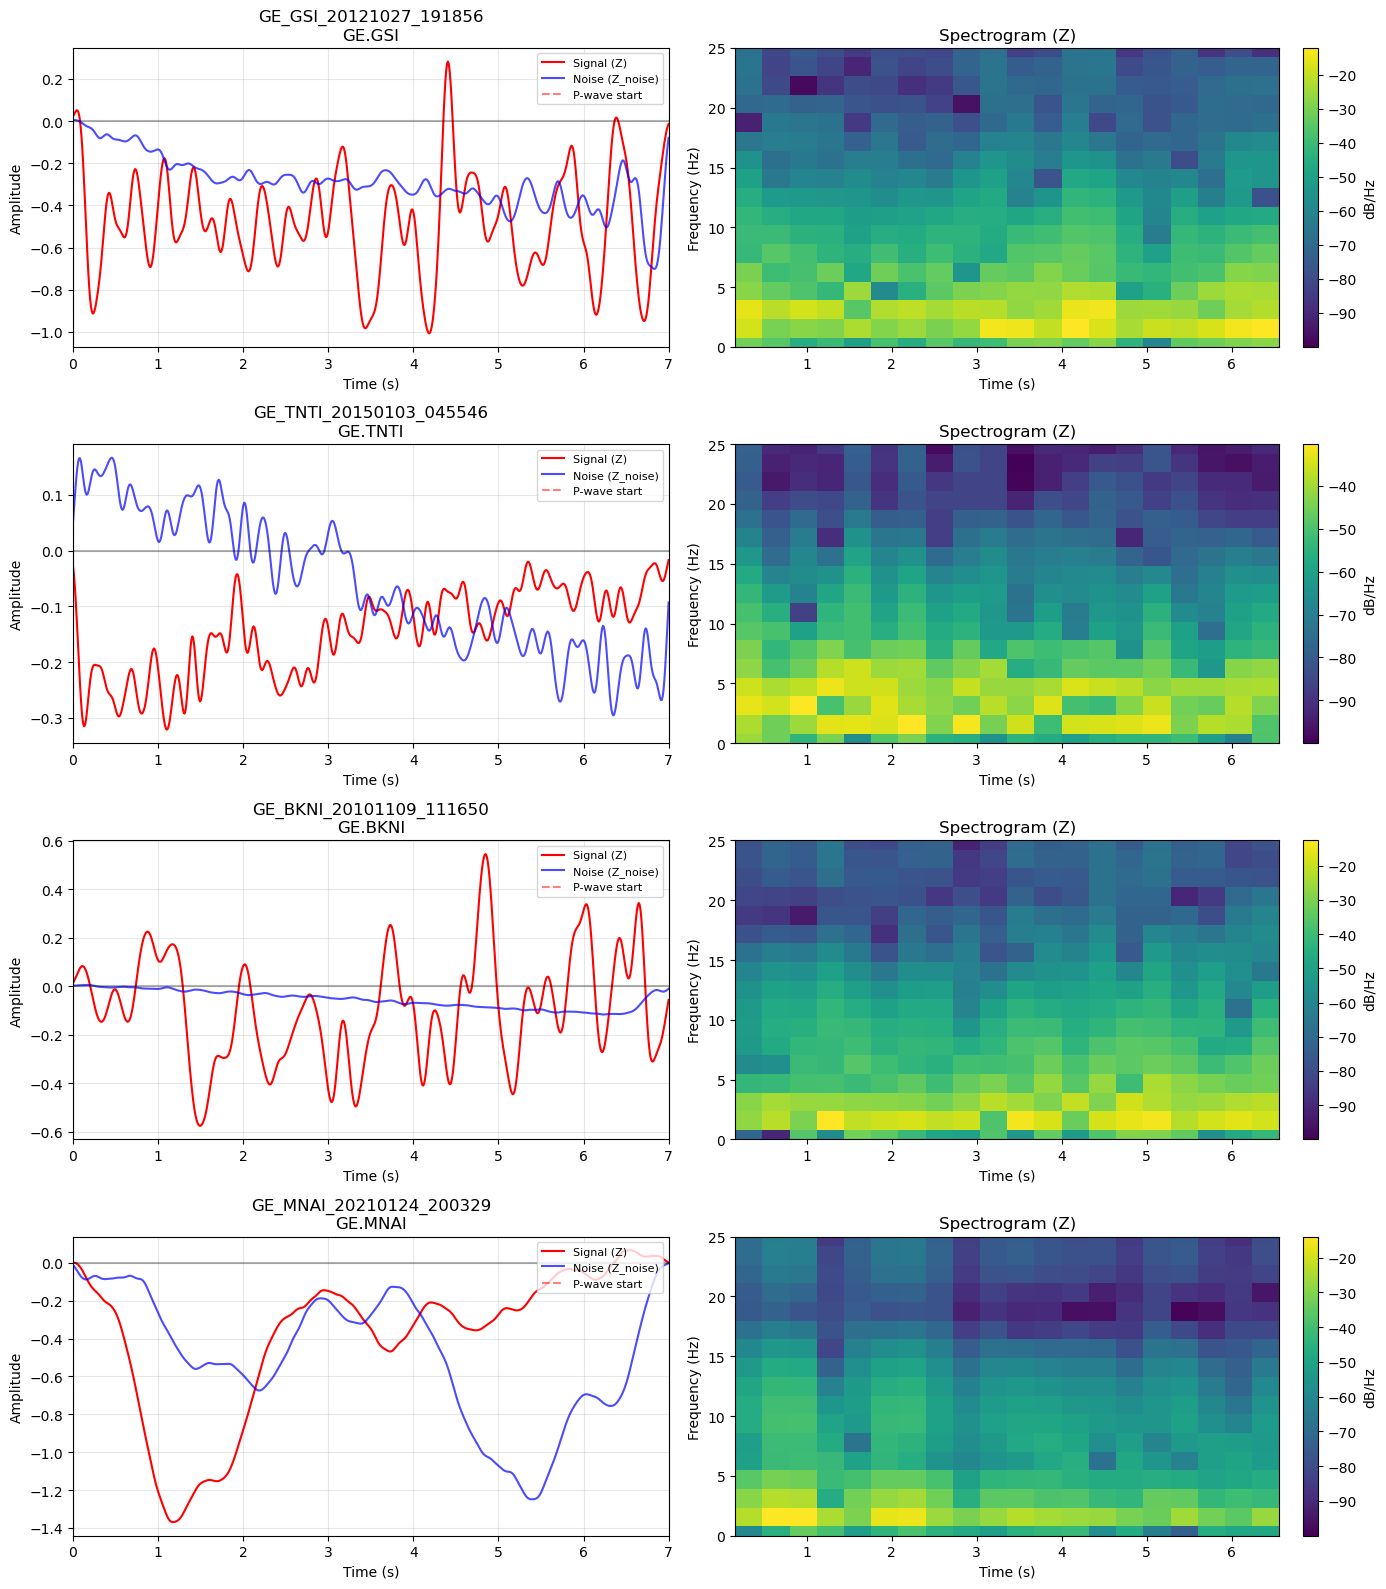

✅ Selesai!


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI SAMPLE DATA DARI JSON MCU-QUAKE
Menampilkan waveform dan spektogram untuk beberapa event.
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

# =============================================
# 1. KONFIGURASI
# =============================================

JSON_PATH = "/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c.json"
N_SAMPLES = 4  # jumlah event yang akan diplot

# =============================================
# 2. LOAD JSON
# =============================================

print("📂 Load JSON...")
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"✅ Total event: {len(data)}")

# Pilih sample acak
keys = list(data.keys())
selected = random.sample(keys, min(N_SAMPLES, len(keys)))

print(f"📊 Sample event: {selected}")

# =============================================
# 3. PLOT
# =============================================

fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(14, 4 * N_SAMPLES))
if N_SAMPLES == 1:
    axes = [axes]

for idx, key in enumerate(selected):
    record = data[key]
    z_signal = np.array(record['Z'])
    z_noise = np.array(record['Z_noise'])
    metadata = record.get('metadata', {})
    station = metadata.get('station', 'UNK')
    network = metadata.get('network', 'UNK')
    
    time = np.linspace(0, 7, len(z_signal))
    
    # --- Kolom kiri: Waveform ---
    ax1 = axes[idx][0] if N_SAMPLES > 1 else axes[0]
    ax1.plot(time, z_signal, color='red', linewidth=1.5, label='Signal (Z)')
    ax1.plot(time, z_noise, color='blue', linewidth=1.5, label='Noise (Z_noise)', alpha=0.7)
    ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax1.axvline(0, color='red', linestyle='--', alpha=0.5, label='P-wave start')
    ax1.set_title(f'{key}\n{network}.{station}')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 7)
    
    # --- Kolom kanan: Spektogram ---
    ax2 = axes[idx][1] if N_SAMPLES > 1 else axes[1]
    f, t, Sxx = signal.spectrogram(z_signal, fs=100, nperseg=64, noverlap=32)
    im = ax2.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), cmap='viridis', shading='auto')
    ax2.set_title('Spectrogram (Z)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Frequency (Hz)')
    ax2.set_ylim(0, 25)
    plt.colorbar(im, ax=ax2, label='dB/Hz', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("✅ Selesai!")